In [124]:
import pandas as pd
import os

### Loading Raw SNP Data

In [125]:
# Download the file PGC3_SCZ_wave3.primary.autosome.public.v3.vcf.tsv from the url below
# https://figshare.com/articles/dataset/scz2022/19426775
raw_df = pd.read_csv(
    os.getcwd() + "/PGC3_SCZ_wave3.primary.autosome.public.v3.vcf.tsv",
    sep='\t',
    comment='#')
raw_df.head(20)


/var/folders/s1/kskcz1f94k71n1l5_1zw1kv40000gn/T/ipykernel_13455/1132601122.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(


,CHROM,ID,POS,A1,A2,FCAS,FCON,IMPINFO,BETA,SE,PVAL,NGT,DIRE,NCAS,NCON,NEFFDIV2
0,8,rs117278216,100516008.0,T,C,0.983,0.983,0.904,-0.010404,0.0366,0.776200,0.0,-??,67390.0,94015.0,78506.50
1,8,rs62513865,101592213.0,C,T,0.937,0.932,0.949,0.014100,0.0169,0.405300,2.0,---,74776.0,101023.0,85057.37
2,8,rs79643588,106973048.0,G,A,0.895,0.900,0.997,-0.003697,0.0134,0.781900,2.0,+--,74776.0,101023.0,85057.37
3,8,rs17396518,108690829.0,T,G,0.488,0.510,0.980,0.001299,0.0077,0.868100,18.0,+-+,74776.0,101023.0,85057.37
4,8,rs983166,108681675.0,A,C,0.538,0.549,0.984,0.004997,0.0075,0.501400,2.0,+++,74776.0,101023.0,85057.37
5,8,rs12546060,105178584.0,G,A,0.564,0.575,0.998,-0.013998,0.0075,0.063730,2.0,+++,74776.0,101023.0,85057.37
6,8,rs28842593,103044620.0,T,C,0.846,0.853,0.939,-0.003005,0.0108,0.782000,3.0,--+,74776.0,101023.0,85057.37
7,8,rs76472819,103183288.0,G,A,0.956,0.955,0.952,-0.011597,0.0185,0.531000,2.0,+++,74776.0,101023.0,85057.37
8,8,rs7841196,105213314.0,A,G,0.908,0.920,1.000,0.008295,0.0134,0.532900,2.0,+++,74776.0,101023.0,85057.37
9,8,rs16897514,100644313.0,G,A,0.825,0.829,0.997,-0.011698,0.0102,0.248600,2.0,+--,74776.0,101023.0,85057.37


### Data Cleaning: Filtering for High Quality, High Impact SNPs. 

In [126]:
print(f"Currently there are {raw_df.shape[0]} rows.")
df = raw_df[raw_df["IMPINFO"] > .8]
df = df[df["PVAL"] <  5e-8]
#df = df.sort_values(by = ["BETA", "PVAL"], ascending=[False,True])
print(f"After filtering for high quality and low p-value rows, there are {df.shape[0]} rows.")
#df = df.sort_values(by= "BETA", ascending = False)
#print("These are the top 10 SNPs that increase schizophrenia risk")
df.head(10)

Currently there are 7585077 rows.
After filtering for high quality and low p-value rows, there are 21539 rows.


,CHROM,ID,POS,A1,A2,FCAS,FCON,IMPINFO,BETA,SE,PVAL,NGT,DIRE,NCAS,NCON,NEFFDIV2
395,8,rs1434281,103671080.0,G,A,0.683,0.670,0.987,0.045499,0.0080,1.083000e-08,2.0,---,74776.0,101023.0,85057.37
3875,8,rs3191333,103662219.0,G,A,0.682,0.669,0.984,0.043701,0.0080,4.398000e-08,24.0,---,74776.0,101023.0,85057.37
4407,8,rs7835270,103668320.0,A,G,0.683,0.670,0.987,0.045203,0.0080,1.351000e-08,2.0,+++,74776.0,101023.0,85057.37
5161,8,rs10106298,103688381.0,G,A,0.679,0.667,0.961,0.045002,0.0081,2.491000e-08,16.0,-+-,74776.0,101023.0,85057.37
5603,8,rs17773903,103685172.0,A,G,0.680,0.669,0.972,0.043998,0.0081,4.777000e-08,4.0,+-+,74776.0,101023.0,85057.37
16563,8,rs7002992,103676605.0,T,C,0.673,0.662,0.980,0.044696,0.0080,1.900000e-08,3.0,+-+,74776.0,101023.0,85057.37
22113,8,rs4734654,103669991.0,A,G,0.683,0.670,0.988,0.045403,0.0080,1.204000e-08,58.0,+++,74776.0,101023.0,85057.37
24423,8,rs13275089,103662852.0,T,C,0.680,0.667,0.983,0.043596,0.0080,4.314000e-08,2.0,+++,74776.0,101023.0,85057.37
44959,2,rs3749051,2334877.0,A,G,0.786,0.784,0.962,-0.050999,0.0093,3.689000e-08,6.0,--+,74776.0,101023.0,85057.37
48235,2,rs6727254,2318592.0,G,A,0.759,0.762,0.977,-0.048697,0.0089,3.830000e-08,2.0,++-,74776.0,101023.0,85057.37


### Manhattan Plot

/var/folders/s1/kskcz1f94k71n1l5_1zw1kv40000gn/T/ipykernel_4655/1444094628.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/s1/kskcz1f94k71n1l5_1zw1kv40000gn/T/ipykernel_4655/1444094628.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("results/manhattan_plot.png", dpi=300, bbox_inches="tight")
/opt/miniconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


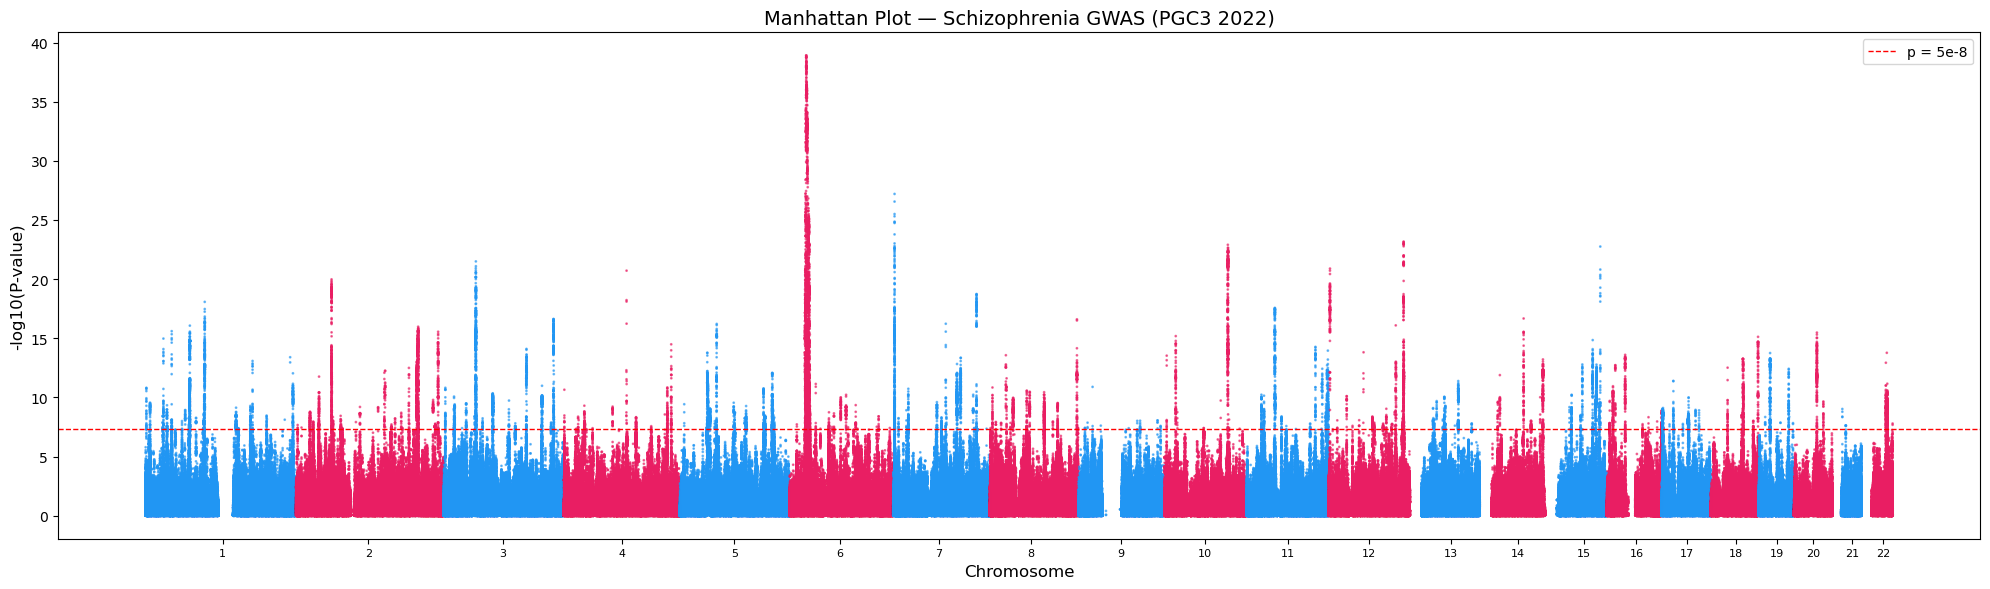

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
def manhattan_plot(df):
    plot_df = raw_df[raw_df["IMPINFO"] > 0.8].copy()
    
    # compute -log10(pval)
    plot_df["-log10P"] = -np.log10(plot_df["PVAL"])
    
    # make sure CHROM is int
    plot_df["CHROM"] = plot_df["CHROM"].astype(int)
    plot_df = plot_df.sort_values(["CHROM", "POS"])
    
    # vectorized cumulative position — much faster than apply
    chrom_max = plot_df.groupby("CHROM")["POS"].max().cumsum().shift(1).fillna(0)
    plot_df["CUM_POS"] = plot_df["POS"] + plot_df["CHROM"].map(chrom_max)
    
    # colors
    colors = ["#2196F3", "#E91E63"]
    chrom_colors = {chrom: colors[i % 2] for i, chrom in enumerate(range(1, 23))}
    plot_df["COLOR"] = plot_df["CHROM"].map(chrom_colors)
    
    # plot
    fig, ax = plt.subplots(figsize=(20, 6))
    
    ax.scatter(
        plot_df["CUM_POS"],
        plot_df["-log10P"],
        c=plot_df["COLOR"],
        s=1,
        alpha=0.6
    )
    
    # significance line
    ax.axhline(y=-np.log10(5e-8), color="red", linestyle="--", linewidth=1, label="p = 5e-8")
    
    # chromosome labels
    chrom_centers = plot_df.groupby("CHROM")["CUM_POS"].mean()
    ax.set_xticks(chrom_centers.values)
    ax.set_xticklabels(chrom_centers.index, fontsize=8)
    ax.set_xlabel("Chromosome", fontsize=12)
    ax.set_ylabel("-log10(P-value)", fontsize=12)
    ax.set_title("Manhattan Plot — Schizophrenia GWAS (PGC3 2022)", fontsize=14)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig("results/manhattan_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

manhattan_plot(raw_df)

### LD Pruning

In [128]:
def ld_prune_positional(df, window_kb=250):
    # work with significant SNPs only
    sig_df = df[df["PVAL"] < 5e-8].copy()
    sig_df = sig_df.sort_values("PVAL", ascending=True)
    
    window_bp = window_kb * 1000
    kept_snps = []
    
    # for each chromosome separately
    for chrom in sig_df["CHROM"].unique():
        chrom_df = sig_df[sig_df["CHROM"] == chrom].copy()
        used_positions = []
        
        # iterate from most to least significant
        for _, row in chrom_df.iterrows():
            pos = row["POS"]
            # check if this SNP is too close to an already kept SNP
            too_close = any(abs(pos - kept_pos) < window_bp 
                          for kept_pos in used_positions)
            if not too_close:
                kept_snps.append(row)
                used_positions.append(pos)
    
    pruned_df = pd.DataFrame(kept_snps)
    return pruned_df

pruned_df = ld_prune_positional(raw_df)
print(f"Before LD pruning: {len(df):,} significant SNPs")
print(f"After LD pruning:  {len(pruned_df):,} independent loci")

Before LD pruning: 21,539 significant SNPs
After LD pruning:  355 independent loci


In [129]:
pruned_df.head(5)

,CHROM,ID,POS,A1,A2,FCAS,FCON,IMPINFO,BETA,SE,PVAL,NGT,DIRE,NCAS,NCON,NEFFDIV2
2572328,6,rs140365013,27523869.0,G,A,0.931,0.914,0.999,0.205696,0.0156,1.205000e-39,2.0,-+-,74776.0,101023.0,85057.37
2541846,6,rs71559050,27797416.0,C,A,0.927,0.910,0.999,0.209199,0.0159,1.548000e-39,0.0,-??,67390.0,94015.0,78506.50
2575012,6,rs67297533,28141253.0,G,T,0.928,0.911,1.000,0.206998,0.0160,2.770000e-38,1.0,-??,67390.0,94015.0,78506.50
2558819,6,rs34676049,28453618.0,T,G,0.933,0.916,0.985,0.202100,0.0159,6.659000e-37,3.0,+-+,74776.0,101023.0,85057.37
2549024,6,rs13207082,27251379.0,A,G,0.934,0.919,0.996,0.198498,0.0160,1.986000e-35,24.0,+-+,74776.0,101023.0,85057.37


### Annotating SNPs (Gene Mapping and Filtering for SNPs that fall directly on Genes)

In [130]:
import requests
import time
test_rsid = pruned_df["ID"].iloc[0]
print(f"Testing with rsID: {test_rsid}")

url = f"https://rest.ensembl.org/vep/human/id/{test_rsid}?content-type=application/json"
response = requests.get(url, timeout=10)

print(f"Status code: {response.status_code}")
print(f"Response: {response.json()}")

Testing with rsID: rs140365013
Status code: 200
Response: [{'most_severe_consequence': 'downstream_gene_variant', 'start': 27556090, 'allele_string': 'G/A', 'id': 'rs140365013', 'end': 27556090, 'seq_region_name': '6', 'transcript_consequences': [{'consequence_terms': ['downstream_gene_variant'], 'gene_id': 'ENSG00000219738', 'variant_allele': 'A', 'transcript_id': 'ENST00000405625', 'biotype': 'processed_pseudogene', 'hgnc_id': 'HGNC:13946', 'impact': 'MODIFIER', 'distance': 4732, 'strand': -1, 'gene_symbol': 'CD83P1', 'gene_symbol_source': 'HGNC'}], 'assembly_name': 'GRCh38', 'strand': 1, 'colocated_variants': [{'pubmed': [35396580, 37207277, 34382107, 36878965, 39936280, 39753749], 'phenotype_or_disease': 1, 'allele_string': 'G/A', 'id': 'rs140365013', 'strand': 1, 'frequencies': {'A': {'eur': 0.0706, 'gnomadg_nfe': 0.08931, 'amr': 0.0389, 'afr': 0.0106, 'eas': 0, 'gnomadg_ami': 0.1449, 'gnomadg_afr': 0.02668, 'gnomadg_eas': 0, 'gnomadg': 0.05585, 'gnomadg_amr': 0.03705, 'sas': 0.00

In [131]:
import requests
import time
import os

def map_all_snps_batch(pruned_df, batch_size=50):
    rsids = pruned_df["ID"].dropna().tolist()
    total_batches = len(rsids) // batch_size + 1
    print(f"Mapping {len(rsids)} SNPs in batches of {batch_size}...")
    
    url = "https://rest.ensembl.org/vep/human/id"
    headers = {
        "Content-Type": "application/json",
        "Accept": "application/json"
    }
    
    results = {}
    
    for i in range(0, len(rsids), batch_size):
        batch = rsids[i:i+batch_size]
        payload = {"ids": batch}
        
        for attempt in range(3):
            try:
                response = requests.post(
                    url, headers=headers,
                    json=payload, timeout=120
                )
                if response.status_code == 200:
                    for item in response.json():
                        rsid = item.get("id")
                        consequences = item.get("transcript_consequences", [])
                        most_severe = item.get("most_severe_consequence", None)
                        
                        if consequences:
                            protein_coding = [c for c in consequences
                                            if c.get("biotype") == "protein_coding"]
                            lncrna = [c for c in consequences
                                     if c.get("biotype") == "lncRNA"]
                            
                            if protein_coding:
                                gene = protein_coding[0].get("gene_symbol", None)
                                biotype = "protein_coding"
                            elif lncrna:
                                gene = lncrna[0].get("gene_symbol", None)
                                biotype = "lncRNA"
                            else:
                                gene = consequences[0].get("gene_symbol", None)
                                biotype = consequences[0].get("biotype", None)
                        else:
                            gene, most_severe, biotype = None, None, None
                        
                        results[rsid] = (gene, most_severe, biotype)
                    break
                    
            except requests.exceptions.Timeout:
                print(f"  Batch {i//batch_size + 1} attempt {attempt+1} timed out, retrying...")
                time.sleep(5)
        
        print(f"Batch {i//batch_size + 1}/{total_batches} done — {len(results)} SNPs mapped")
        time.sleep(2)
    
    result_df = pruned_df.copy()
    result_df["GENE"]        = result_df["ID"].map(lambda x: results.get(x, (None,None,None))[0])
    result_df["CONSEQUENCE"] = result_df["ID"].map(lambda x: results.get(x, (None,None,None))[1])
    result_df["BIOTYPE"]     = result_df["ID"].map(lambda x: results.get(x, (None,None,None))[2])
    
    return result_df
strong = ["missense_variant", "splice_region_variant", 
          "splice_polypyrimidine_tract_variant",
          "5_prime_UTR_variant", "3_prime_UTR_variant",
          "synonymous_variant", "intron_variant"]

# run — adjust batch_size down if you get timeouts
if not os.path.exists("results/mapped_snps.csv"):
    print("Computing mapped_snps.csv:")
    mapped_df = map_all_snps_batch(pruned_df, batch_size=50)
    mapped_df.to_csv("results/mapped_snps.csv", index=False)
    print("Saved to results/mapped_snps.csv")
else:
    mapped_df = pd.read_csv("results/mapped_snps.csv")
    print("Loaded existing results/mapped_snps.csv")

print(f"\nMapped:   {mapped_df['GENE'].notna().sum()}")
print(f"Unmapped: {mapped_df['GENE'].isna().sum()}")
print("\nBiotype breakdown:")
print(mapped_df["BIOTYPE"].value_counts())

Loaded existing results/mapped_snps.csv

Mapped:   252
Unmapped: 103

Biotype breakdown:
BIOTYPE
protein_coding                    210
lncRNA                             85
processed_pseudogene                3
protein_coding_CDS_not_defined      3
nonsense_mediated_decay             1
unitary_pseudogene                  1
Name: count, dtype: int64


In [123]:
print("These are the top 15 SNPs and their related genes that are the most associated to increased schizophrenia risk")
top15_df = mapped_df[mapped_df["CONSEQUENCE"].isin(strong)]
top15_df["ABS_BETA"] = top15_df["BETA"].abs()
top15_df = top15_df[top15_df["GENE"].notna()].copy()

top15_df = top15_df[top15_df["GENE"].notna()].sort_values(by = "ABS_BETA", ascending = False).head(15)
top15_df.to_csv("results/top15_SNPs.csv", index=False)
top15_df


These are the top 15 SNPs and their related genes that are the most associated to increased schizophrenia risk


/var/folders/s1/kskcz1f94k71n1l5_1zw1kv40000gn/T/ipykernel_13455/1689287253.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top15_df["ABS_BETA"] = top15_df["BETA"].abs()


,CHROM,ID,POS,A1,A2,FCAS,FCON,IMPINFO,BETA,SE,PVAL,NGT,DIRE,NCAS,NCON,NEFFDIV2,GENE,CONSEQUENCE,BIOTYPE,ABS_BETA
6,6,rs72843784,26498758.0,G,T,0.937,0.921,0.997,0.201397,0.0163,5.225000e-35,8.0,-+-,74776.0,101023.0,85057.37,BTN1A1,intron_variant,protein_coding,0.201397
11,6,rs34961555,26199903.0,C,T,0.940,0.925,0.975,0.188999,0.0169,4.020000e-29,2.0,-+-,74776.0,101023.0,85057.37,H2AC7,synonymous_variant,protein_coding,0.188999
291,18,rs76888488,53311001.0,A,G,0.967,0.972,0.990,-0.170895,0.0250,7.894000e-12,1.0,-?-,68624.0,97105.0,80270.17,TCF4,intron_variant,protein_coding,0.170895
12,6,rs2023473,30075613.0,T,C,0.919,0.901,0.946,0.169802,0.0152,5.455000e-29,3.0,+-+,74776.0,101023.0,85057.37,TRIM31,intron_variant,protein_coding,0.169802
20,6,rs13198474,25874423.0,G,A,0.944,0.930,0.974,0.165997,0.0174,1.840000e-21,22.0,-+-,74776.0,101023.0,85057.37,SLC17A3,5_prime_UTR_variant,protein_coding,0.165997
22,6,rs215011,25384361.0,C,T,0.950,0.943,0.958,0.165904,0.0184,2.289000e-19,8.0,---,74776.0,101023.0,85057.37,CARMIL1,intron_variant,protein_coding,0.165904
288,18,rs74914300,53010348.0,T,G,0.957,0.963,0.993,-0.161696,0.0217,1.042000e-13,1.0,-?-,68624.0,97105.0,80270.17,TCF4,intron_variant,protein_coding,0.161696
136,4,rs13107325,103188709.0,C,T,0.925,0.936,0.975,-0.156701,0.0165,1.919000e-21,68.0,+++,74776.0,101023.0,85057.37,SLC39A8,missense_variant,protein_coding,0.156701
17,6,rs9262135,30618906.0,A,G,0.912,0.894,0.942,0.152498,0.0147,3.755000e-25,54.0,+-+,74776.0,101023.0,85057.37,C6orf136,intron_variant,protein_coding,0.152498
15,6,rs3117577,31727474.0,A,G,0.913,0.896,1.010,0.148903,0.0142,7.946000e-26,51.0,++-,74776.0,101023.0,85057.37,MSH5,intron_variant,protein_coding,0.148903


### Pathway Enrichment (which biological pathways are overrepresented in schizophrenia-associated genes)

In [135]:
import gseapy as gp

m = mapped_df[mapped_df["CONSEQUENCE"].isin(strong)]
gene_list = m["GENE"].dropna().unique().tolist()
print(f"Running pathway enrichment on {len(gene_list)} genes...")

result = gp.enrichr(
    gene_list=gene_list,
    gene_sets= [
        "GO_Biological_Process_2023",
        "KEGG_2021_Human",
        "Reactome_2022",
        "WikiPathways_2023_Human",
        "GO_Molecular_Function_2023",
        "SynGO_2022"
    ],
    organism="human",
    outdir=None,
    cutoff=0.05
)

enrich_df = result.results
sig_df = enrich_df[enrich_df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")

print(f"Significant pathways found: {len(sig_df)}")
print(sig_df[["Gene_set", "Term", "Adjusted P-value", "Genes"]].head(20))

sig_df.to_csv("results/pathway_results.csv", index=False)
print("Saved to results/pathway_results.csv")

Running pathway enrichment on 214 genes...


2026-03-31 12:50:17,930 [WARNING] Input library not found: WikiPathways_2023_Human. Skip


Significant pathways found: 20
                        Gene_set  \
0     GO_Biological_Process_2023   
1     GO_Biological_Process_2023   
2     GO_Biological_Process_2023   
2237                  SynGO_2022   
1982  GO_Molecular_Function_2023   
1984  GO_Molecular_Function_2023   
1983  GO_Molecular_Function_2023   
1985  GO_Molecular_Function_2023   
1238             KEGG_2021_Human   
1239             KEGG_2021_Human   
2238                  SynGO_2022   
1240             KEGG_2021_Human   
1241             KEGG_2021_Human   
2241                  SynGO_2022   
2239                  SynGO_2022   
2240                  SynGO_2022   
1432               Reactome_2022   
1431               Reactome_2022   
1430               Reactome_2022   
1986  GO_Molecular_Function_2023   

                                                   Term  Adjusted P-value  \
0                       Calcium Ion Import (GO:0070509)          0.007302   
1                    Generation Of Neurons (GO:0048699)   

In [136]:
sig_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Calcium Ion Import (GO:0070509),4/12,0.000006,0.007302,0,0,47.090476,567.010456,CACNB2;TRPC4;TRPV4;CACNA1D
1,GO_Biological_Process_2023,Generation Of Neurons (GO:0048699),10/172,0.000017,0.009845,0,0,5.938030,65.244910,PTPRD;GPM6A;EMX1;MEF2C;MYT1L;FUT9;DCC;LRP4;MAP...
2,GO_Biological_Process_2023,Calcium Ion Transmembrane Transport (GO:0070588),7/80,0.000024,0.009845,0,0,9.131824,97.193611,GRIN2A;TRPC4;TRPV4;ATP2A2;CACNA1D;CACNA1C;NALCN
2237,SynGO_2022,Integral Component Of Postsynaptic Density Mem...,6/82,0.000249,0.010210,0,0,7.481022,62.077254,GRIN2A;DCC;ADGRB3;SORCS3;GRM1;LRRC4B
1982,GO_Molecular_Function_2023,Calcium Channel Activity (GO:0005262),7/91,0.000055,0.010452,0,0,7.931562,77.787595,CACNB2;CACNA1I;TRPC4;TRPV4;CACNA2D2;CACNA1D;CA...
1984,GO_Molecular_Function_2023,Voltage-Gated Calcium Channel Activity (GO:000...,5/47,0.000142,0.010452,0,0,11.246298,99.604253,CACNA1I;CACNB2;CACNA2D2;CACNA1D;CACNA1C
1983,GO_Molecular_Function_2023,High Voltage-Gated Calcium Channel Activity (G...,4/23,0.000096,0.010452,0,0,19.816541,183.285010,CACNA1I;CACNB2;CACNA1D;CACNA1C
1985,GO_Molecular_Function_2023,Voltage-Gated Monoatomic Cation Channel Activi...,6/76,0.000164,0.010452,0,0,8.124725,70.814332,KCNG2;CACNB2;CACNA1I;CACNA2D2;CACNA1D;CACNA1C
1238,KEGG_2021_Human,GnRH secretion,6/64,0.000063,0.012008,0,0,9.811671,94.973812,CACNA1I;GABBR2;TRPC4;AKT3;CACNA1D;CACNA1C
1239,KEGG_2021_Human,Arrhythmogenic right ventricular cardiomyopathy,6/77,0.000176,0.016919,0,0,8.009886,69.234550,CACNB2;SGCD;ATP2A2;CACNA2D2;CACNA1D;CACNA1C


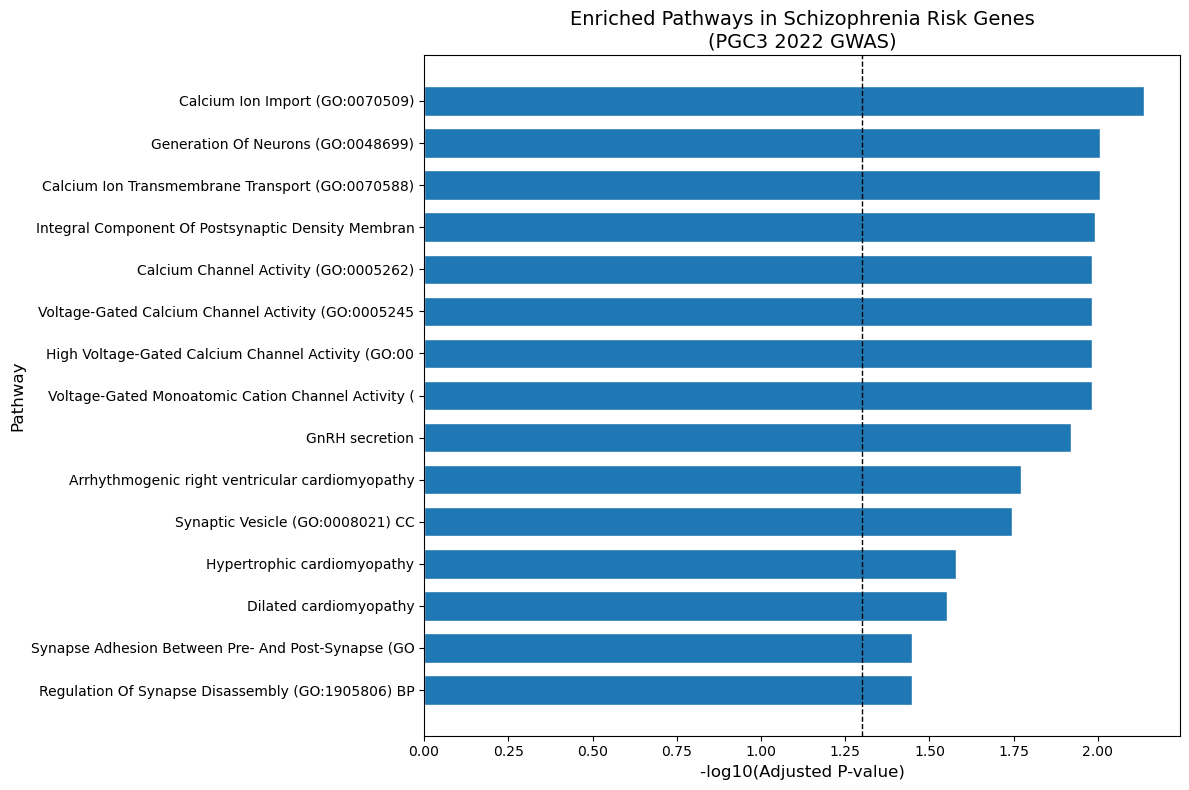

Saved to results/pathway_enrichment.png


In [137]:
import matplotlib.pyplot as plt
import numpy as np

# get top 15 significant pathways
top_pathways = sig_df.head(15).copy()

# shorten long names for display
top_pathways["Short_Term"] = top_pathways["Term"].str[:50]

# -log10 adjusted p-value for x axis
top_pathways["-log10_adjP"] = -np.log10(top_pathways["Adjusted P-value"])

# color by gene set
# colors = top_pathways["Gene_set"].map({
#     "GO_Biological_Process_2023": "#2196F3",
#     "KEGG_2021_Human": "#E74C3C"
# })

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_pathways["Short_Term"],
    top_pathways["-log10_adjP"],
    #color=colors,
    edgecolor="white",
    height=0.7
)

# significance line at p=0.05
ax.axvline(
    x=-np.log10(0.05),
    color="black",
    linestyle="--",
    linewidth=1,
    label="p = 0.05"
)

ax.set_xlabel("-log10(Adjusted P-value)", fontsize=12)
ax.set_ylabel("Pathway", fontsize=12)
ax.set_title("Enriched Pathways in Schizophrenia Risk Genes\n(PGC3 2022 GWAS)", fontsize=14)

# legend for database colors
from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor="#2196F3", label="GO Biological Process"),
#     Patch(facecolor="#E74C3C", label="KEGG")
# ]
# ax.legend(handles=legend_elements, fontsize=10)

# invert y axis so most significant at top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("results/pathway_enrichment.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to results/pathway_enrichment.png")

In [138]:
print(sig_df[["Term", "Overlap", "Adjusted P-value", "Genes"]].head(15))

                                                   Term Overlap  \
0                       Calcium Ion Import (GO:0070509)    4/12   
1                    Generation Of Neurons (GO:0048699)  10/172   
2      Calcium Ion Transmembrane Transport (GO:0070588)    7/80   
2237  Integral Component Of Postsynaptic Density Mem...    6/82   
1982              Calcium Channel Activity (GO:0005262)    7/91   
1984  Voltage-Gated Calcium Channel Activity (GO:000...    5/47   
1983  High Voltage-Gated Calcium Channel Activity (G...    4/23   
1985  Voltage-Gated Monoatomic Cation Channel Activi...    6/76   
1238                                     GnRH secretion    6/64   
1239    Arrhythmogenic right ventricular cardiomyopathy    6/77   
2238                   Synaptic Vesicle (GO:0008021) CC    3/18   
1240                        Hypertrophic cardiomyopathy    6/90   
1241                             Dilated cardiomyopathy    6/96   
2241  Synapse Adhesion Between Pre- And Post-Synapse...    3/3

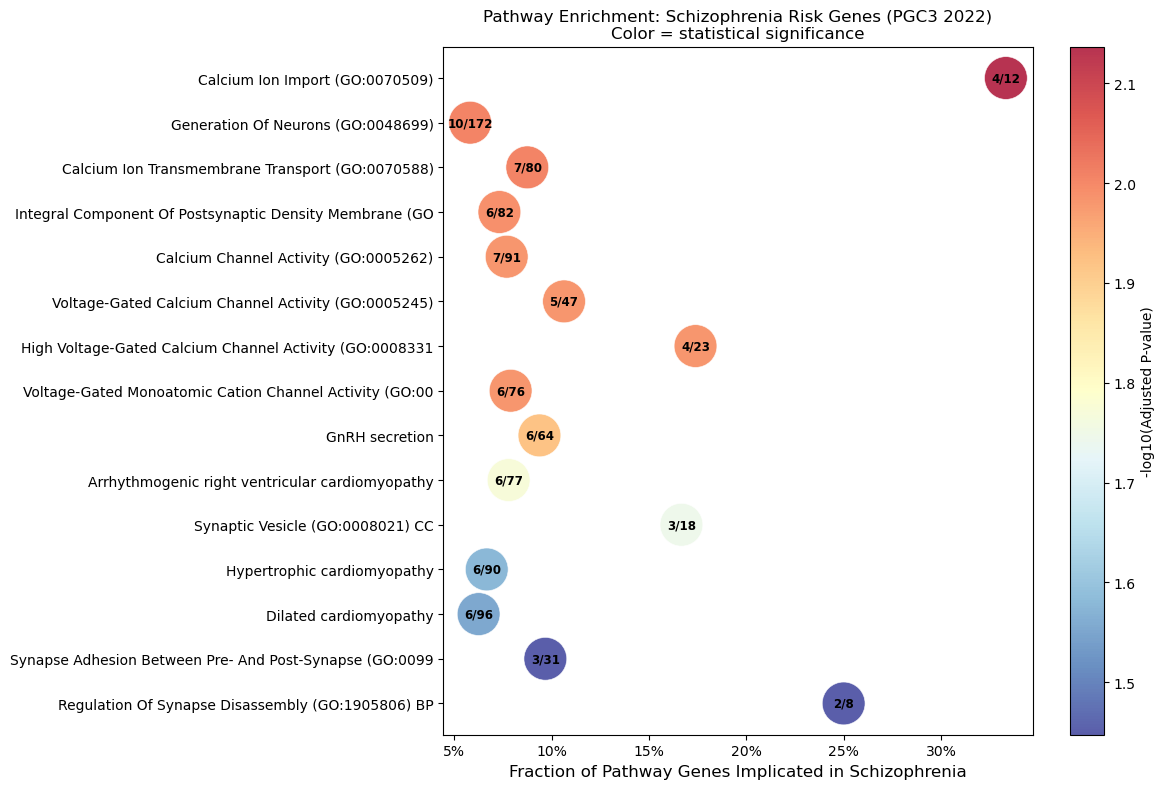

Saved to results/pathway_bubble_plot.png


In [139]:
import matplotlib.pyplot as plt
import numpy as np

# parse overlap into ratio
sig_df["Overlap_num"] = sig_df["Overlap"].apply(lambda x: int(x.split("/")[0]))
sig_df["Overlap_denom"] = sig_df["Overlap"].apply(lambda x: int(x.split("/")[1]))
sig_df["Overlap_ratio"] = sig_df["Overlap_num"] / sig_df["Overlap_denom"]
sig_df["-log10_adjP"] = -np.log10(sig_df["Adjusted P-value"])

# top 15
plot_df = sig_df.head(15).copy()
plot_df["Short_Term"] = plot_df["Term"].str[:55]

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    plot_df["Overlap_ratio"],       # x = % of pathway covered
    plot_df["Short_Term"],          # y = pathway name
    s=950,
    c=plot_df["-log10_adjP"],       # color = significance
    cmap="RdYlBu_r",
    alpha=0.8,
    edgecolors="white",
    linewidth=0.5
)

# colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("-log10(Adjusted P-value)", fontsize=10)

# add overlap ratio labels on each bubble
for _, row in plot_df.iterrows():
    ax.annotate(
        row["Overlap"],
        (row["Overlap_ratio"], row["Short_Term"]),
        ha="center",
        va="center",
        fontsize=8.5,
        color="black",
        fontweight="bold"
    )

ax.set_xlabel("Fraction of Pathway Genes Implicated in Schizophrenia", fontsize=12)
ax.set_ylabel("")
ax.set_title(
    "Pathway Enrichment: Schizophrenia Risk Genes (PGC3 2022)\n"
    "Color = statistical significance",
    fontsize=12
)

# x axis as percentage
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

ax.invert_yaxis()
plt.tight_layout()
plt.savefig("results/pathway_bubble_plot.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to results/pathway_bubble_plot.png")
